# Implementing Multiple Linear Regression From First Principles
Data sourced from https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression?select=Student_Performance.csv

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Analysing Data

In [48]:
raw = pd.read_csv('Student_Performance.csv')
raw.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [49]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


In [50]:
raw.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [51]:
# Investigate the non-numerical variable
raw['Extracurricular Activities']

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999     No
Name: Extracurricular Activities, Length: 10000, dtype: str

The dataset does not have any null values, investigate the possibility of a linear relation between variables and performance.

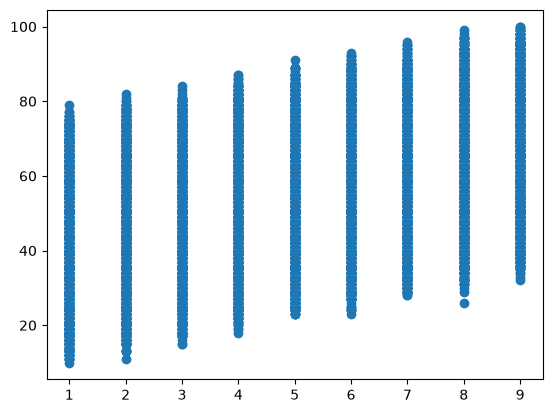

In [52]:
plt.plot(raw['Hours Studied'], raw['Performance Index'], 'o');

There appears to be a positive relation, although unclear if it is linear due to the limiting discrete variable.

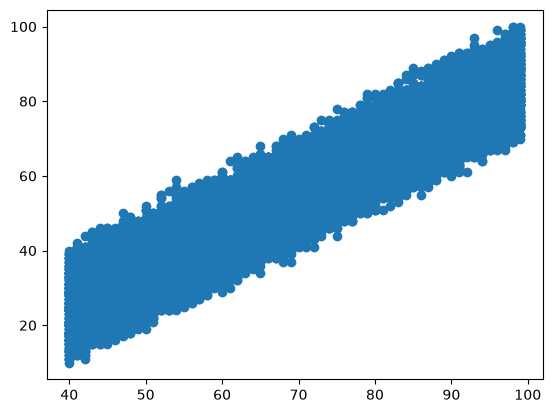

In [53]:
plt.plot(raw['Previous Scores'], raw['Performance Index'], 'o');

There appears to be a strong positive linear relation.

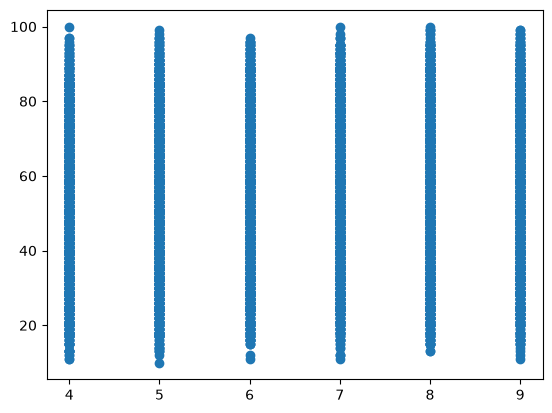

In [54]:
plt.plot(raw['Sleep Hours'], raw['Performance Index'], 'o');

It does not appear as if there is a relation between the variables.

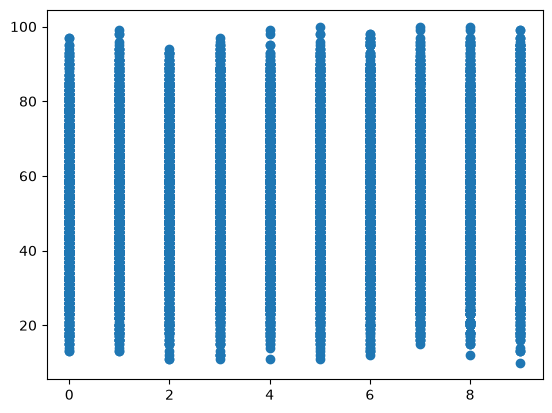

In [55]:
plt.plot(raw['Sample Question Papers Practiced'], raw['Performance Index'], 'o');

It does not appear as if there is a relation between the variables.

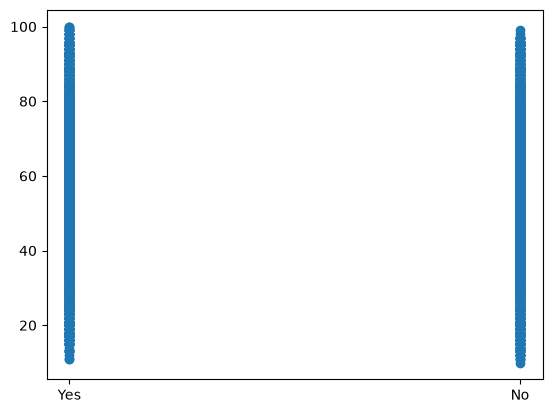

In [56]:
plt.plot(raw['Extracurricular Activities'], raw['Performance Index'], 'o');

It is not clear from the plot whether there is a relation or not, so group by Y/N.

In [57]:
raw_y = raw[raw['Extracurricular Activities'] == 'Yes']
raw_n = raw[raw['Extracurricular Activities'] == 'No']
raw_y['Performance Index'].describe(), raw_n['Performance Index'].describe()

(count    4948.000000
 mean       55.700889
 std        19.264416
 min        11.000000
 25%        41.000000
 50%        55.000000
 75%        71.000000
 max       100.000000
 Name: Performance Index, dtype: float64,
 count    5052.000000
 mean       54.758511
 std        19.152068
 min        10.000000
 25%        40.000000
 50%        55.000000
 75%        70.000000
 max        99.000000
 Name: Performance Index, dtype: float64)

Taking extracurricular activies does not seem to have an impact on performance.

In [58]:
# Determine if the observations are correct
raw.select_dtypes(include=['float64', 'int64']).corrwith(raw['Performance Index'])

Hours Studied                       0.373730
Previous Scores                     0.915189
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Performance Index                   1.000000
dtype: float64

The correlation coefficients seem to match with the expectations.
Hours studied has a moderate positive association with performance, while previous scores has a strong positive association.
Sleep hours and sample question papers have a negligible association with performance.
Due to the discrepancy in strength of association with performance from hours studies and previous scores, train one model on both and another on previous scores alone.

In [59]:
# Split into training and testing data for single and multiple linear regression
train = raw.iloc[:int(0.8*len(raw))]
test = raw.iloc[int(0.8*len(raw)):]
multi_xtrain = train[['Hours Studied', 'Previous Scores']].values
single_xtrain = train[['Previous Scores']].values
ytrain = train['Performance Index'].values
multi_xtest = test[['Hours Studied', 'Previous Scores']].values
single_xtest = test[['Previous Scores']].values
ytest = test['Performance Index'].values

## Single Linear Regression

### Initialising Cost Function, Gradients, and Hyperparameters

In [60]:

def single_J(w, b, x, y):
    n = len(x)
    mse = np.sum((w*x + b - y) ** 2) / (2*n)
    return mse

def single_dJ_dw(w, b, x, y):
    n = len(x)
    return np.sum((w*x + b - y) * x) / n

def single_dJ_db(w, b, x, y):
    n = len(x)
    return np.sum(w*x + b - y) / n

# Fix the learning rate and number of iterations
alpha = 1e-6
num_iterations = 10

### Gradient Descent

In [61]:
# Find the optimal values of w and b using gradient descent
w = 0
b = 0
for i in range(num_iterations):
    temp_w = w - alpha * single_dJ_dw(w, b, single_xtrain, ytrain)
    temp_b = b - alpha * single_dJ_db(w, b, single_xtrain, ytrain)
    w = temp_w
    b = temp_b
w, b

(np.float64(-7822184146839313.0), np.float64(-106025606193459.16))

The values appear to be diverging and not settling, indicating that the inition learning rate was too large.

In [62]:
alpha = 1e-8
num_iterations = 10 ** 2
w = 0
b = 0
for i in range(num_iterations):
    temp_w = w - alpha * single_dJ_dw(w, b, single_xtrain, ytrain)
    temp_b = b - alpha * single_dJ_db(w, b, single_xtrain, ytrain)
    w = temp_w
    b = temp_b
w, b

(np.float64(0.7472978795240179), np.float64(0.036076586070870956))

### Comparing Costs

In [63]:
single_J(0, 0, single_xtrain, ytrain), single_J(w, b, single_xtrain, ytrain)

(np.float64(13654650.0), np.float64(2195282.6093925964))

### Visualisation

Text(0.5, 1.0, 'Residuals')

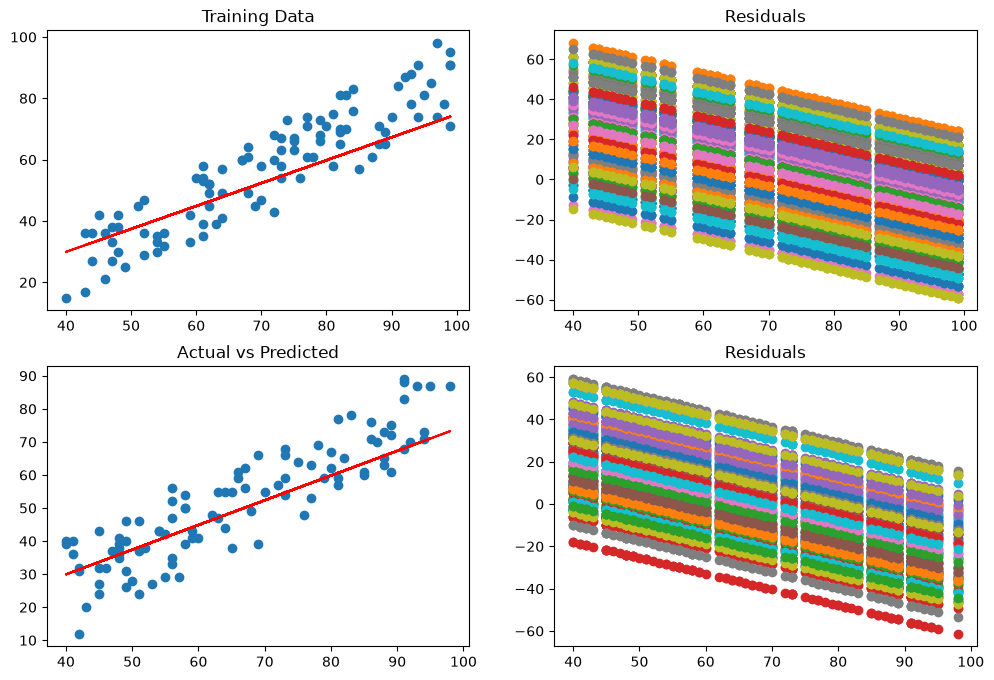

In [64]:
# Visualise a sample of the data
single_xtrain_vis = single_xtrain[:100]
ytrain_vis = ytrain[:100]
single_xtest_vis = single_xtest[:100]
ytest_vis = ytest[:100]
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax1.plot(single_xtrain_vis, ytrain_vis, 'o')
ax1.plot(single_xtrain_vis, w*single_xtrain_vis + b, 'r')
ax2.plot(single_xtrain_vis, ytrain_vis - (w*single_xtrain_vis + b), 'o')
ax3.plot(single_xtest_vis, ytest_vis, 'o')
ax3.plot(single_xtest_vis, w*single_xtest_vis + b, 'r')
ax4.plot(single_xtest_vis, ytest_vis - (w*single_xtest_vis + b), 'o')
ax1.set_title('Training Data')
ax2.set_title('Residuals')
ax3.set_title('Actual vs Predicted')
ax4.set_title('Residuals')

The gradient descent algorithm took 3 minutes for only 100 iterations, and the residual plot seems like several straight lines of dots, indicating a possible broadcasting issue in the numpy arrays.

### Troubleshooting

In [65]:
single_xtrain = single_xtrain.ravel()
single_xtest = single_xtest.ravel()
ytrain = ytrain.ravel()
single_xtrain_vis = single_xtrain[:100]
ytrain_vis = ytrain[:100]
single_xtest_vis = single_xtest[:100]
ytest_vis = ytest[:100]
single_xtrain.shape, ytrain.shape

((8000,), (8000,))

In [66]:
def single_J(w, b, x, y):
    n = len(x)
    mse = np.sum((w*x + b - y) ** 2) / (2*n)
    return mse

def single_dJ_dw(w, b, x, y):
    n = len(x)
    return np.sum((w*x + b - y) * x) / n

def single_dJ_db(w, b, x, y):
    n = len(x)
    return np.sum(w*x + b - y) / n

In [67]:
# We can increase the learning rate and number of iterations
alpha = 1e-6
num_iterations = 10 ** 4
w = 0
b = 0
for i in range(num_iterations):
    temp_w = w - alpha * single_dJ_dw(w, b, single_xtrain, ytrain)
    temp_b = b - alpha * single_dJ_db(w, b, single_xtrain, ytrain)
    w = temp_w
    b = temp_b
w, b

(np.float64(0.8074330696838932), np.float64(0.0019452065534108426))

In [68]:
single_J(0, 0, single_xtrain, ytrain), single_J(w, b, single_xtrain, ytrain)

(np.float64(1706.83125), np.float64(36.7677005453472))

Text(0.5, 1.0, 'Residuals')

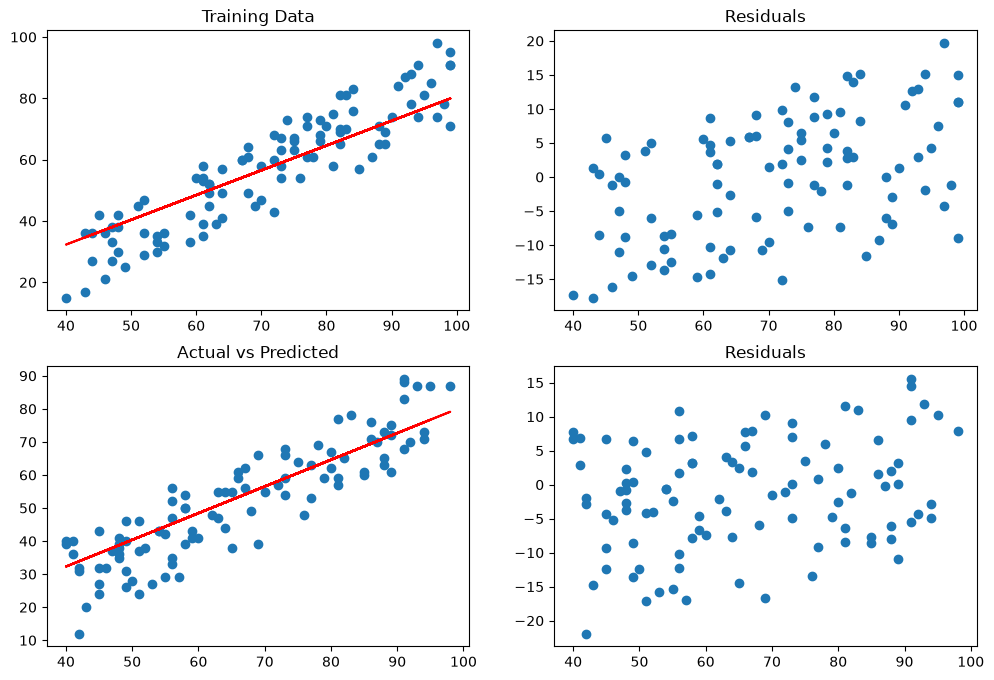

In [69]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax1.plot(single_xtrain_vis, ytrain_vis, 'o')
ax1.plot(single_xtrain_vis, w*single_xtrain_vis + b, 'r')
ax2.plot(single_xtrain_vis, ytrain_vis - (w*single_xtrain_vis + b), 'o')
ax3.plot(single_xtest_vis, ytest_vis, 'o')
ax3.plot(single_xtest_vis, w*single_xtest_vis + b, 'r')
ax4.plot(single_xtest_vis, ytest_vis - (w*single_xtest_vis + b), 'o')
ax1.set_title('Training Data')
ax2.set_title('Residuals')
ax3.set_title('Actual vs Predicted')
ax4.set_title('Residuals')

The residuals appear to have a pattern, so we test a possible correlation

In [70]:
np.corrcoef(single_xtrain, ytrain - (w*single_xtrain + b))[0, 1]

np.float64(0.42201196127471785)

The values of x have a moderate correlation with the residuals, meaning the model has not converged to the solution yet, meaning we must increase the number of iterations and/or increase the learning rate

In [71]:
alpha = 1e-4
num_iterations = 10 ** 6
w = 0
b = 0
for i in range(num_iterations):
    temp_w = w - alpha * single_dJ_dw(w, b, single_xtrain, ytrain)
    temp_b = b - alpha * single_dJ_db(w, b, single_xtrain, ytrain)
    w = temp_w
    b = temp_b
w, b

(np.float64(1.0141855794480215), np.float64(-15.251504052159447))

In [72]:
single_J(0, 0, single_xtrain, ytrain), single_J(w, b, single_xtrain, ytrain)

(np.float64(1706.83125), np.float64(29.887154586818806))

Text(0.5, 1.0, 'Residuals')

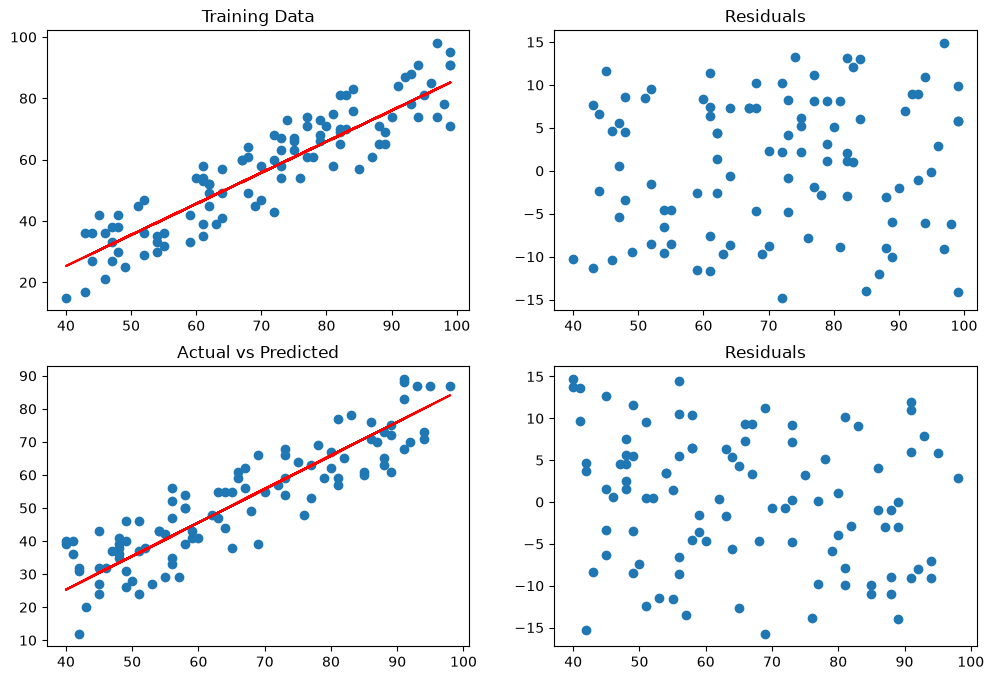

In [73]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax1.plot(single_xtrain_vis, ytrain_vis, 'o')
ax1.plot(single_xtrain_vis, w*single_xtrain_vis + b, 'r')
ax2.plot(single_xtrain_vis, ytrain_vis - (w*single_xtrain_vis + b), 'o')
ax3.plot(single_xtest_vis, ytest_vis, 'o')
ax3.plot(single_xtest_vis, w*single_xtest_vis + b, 'r')
ax4.plot(single_xtest_vis, ytest_vis - (w*single_xtest_vis + b), 'o')
ax1.set_title('Training Data')
ax2.set_title('Residuals')
ax3.set_title('Actual vs Predicted')
ax4.set_title('Residuals')

In [74]:
np.corrcoef(single_xtrain, ytrain - (w*single_xtrain + b))[0, 1]

np.float64(0.0013011359942527308)

The model appears to be an appropriate fit, the residuals do not appear to have a clear pattern, and the correlation coefficient is minimal, indicating the model is a suitable predictor of approximately the form y = 1.0142x - 15.2515. One issue is the processing time for gradient descent, nearly reaching 4 minutes. A learning rate of 1e-3 caused the algorithm to diverge as the inputs were too large, so its possible that using feature scaling and then picking a larger learning rate and lower iteration count would reduce the runtime.

In [75]:
single_xtrain_scaled = (single_xtrain - np.mean(single_xtrain)) / np.std(single_xtrain)
ytrain_scaled = (ytrain - np.mean(ytrain)) / np.std(ytrain)

In [76]:
alpha = 1e-2
num_iterations = 10 ** 3
scaled_w = 0
scaled_b = 0
for i in range(num_iterations):
    temp_w = scaled_w - alpha * single_dJ_dw(scaled_w, scaled_b, single_xtrain_scaled, ytrain_scaled)
    temp_b = scaled_b - alpha * single_dJ_db(scaled_w, scaled_b, single_xtrain_scaled, ytrain_scaled)
    scaled_w = temp_w
    scaled_b = temp_b
scaled_w, scaled_b

(np.float64(0.9156390623489467), np.float64(3.0526248195883457e-16))

In [77]:
w = scaled_w * np.std(ytrain) / np.std(single_xtrain)
b = np.mean(ytrain) + np.std(ytrain) * scaled_b - scaled_w * np.std(ytrain) * np.mean(single_xtrain) / np.std(single_xtrain)
w, b

(np.float64(1.0147213005667224), np.float64(-15.291217668752076))

In [78]:
single_J(0, 0, single_xtrain, ytrain), single_J(w, b, single_xtrain, ytrain)

(np.float64(1706.83125), np.float64(29.887101117718828))

Text(0.5, 1.0, 'Residuals')

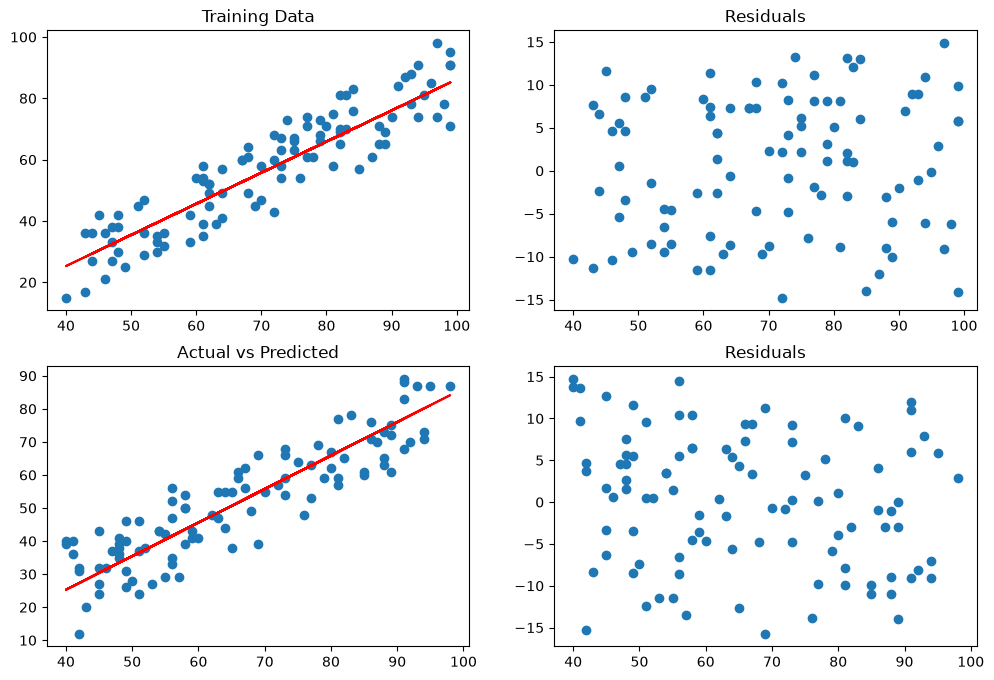

In [79]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax1.plot(single_xtrain_vis, ytrain_vis, 'o')
ax1.plot(single_xtrain_vis, w*single_xtrain_vis + b, 'r')
ax2.plot(single_xtrain_vis, ytrain_vis - (w*single_xtrain_vis + b), 'o')
ax3.plot(single_xtest_vis, ytest_vis, 'o')
ax3.plot(single_xtest_vis, w*single_xtest_vis + b, 'r')
ax4.plot(single_xtest_vis, ytest_vis - (w*single_xtest_vis + b), 'o')
ax1.set_title('Training Data')
ax2.set_title('Residuals')
ax3.set_title('Actual vs Predicted')
ax4.set_title('Residuals')

With the new values of 0.01 for the learning rate and 1000 for the iterations, gradient descent took merely 0.2 seconds, while achieving similar results.

### Evaluation

In [80]:
# Calculate coefficient of determination
y_predicted = w * single_xtest + b
ss_total = np.sum((ytest - np.mean(ytest)) ** 2)
ss_residual = np.sum((ytest - y_predicted) ** 2)
r_2 = 1 - (ss_residual / ss_total)
r_2

np.float64(0.8338765842092313)

The model can explain 83.39% of the variation in student performance.

## Multiple Linear Regression

In [81]:
multi_xtrain.shape, ytrain.shape

((8000, 2), (8000,))

### Initialising Cost Function, Gradients, and Hyperparameters

In [82]:
def multi_J(w, b, x, y):
    n = len(x)
    return np.sum((x.dot(w) + b - y) ** 2) / (2*n)

def multi_dJ_dw(w, b, x, y):
    n = len(x)
    return x.T.dot(x.dot(w) + b - y) / n

def multi_dJ_db(w, b, x, y):
    n = len(x)
    return np.sum(x.dot(w) + b - y) / n

alpha = 1e-2
num_iterations = 10 ** 3

### Feature Scaling

In [83]:
multi_xtrain_scaled = (multi_xtrain - np.mean(multi_xtrain, axis=0)) / np.std(multi_xtrain, axis=0)
ytrain_scaled = (ytrain - np.mean(ytrain)) / np.std(ytrain)

### Gradient Descent

In [84]:
# Gradient descent
scaled_w = np.zeros(multi_xtrain_scaled.shape[1])
scaled_b = 0
for i in range(num_iterations):
    temp_w = scaled_w - alpha * multi_dJ_dw(scaled_w, scaled_b, multi_xtrain_scaled, ytrain_scaled)
    temp_b = scaled_b - alpha * multi_dJ_db(scaled_w, scaled_b, multi_xtrain_scaled, ytrain_scaled)
    scaled_w = temp_w
    scaled_b = temp_b

# Unscale the parameters to get the original scale
w = scaled_w * np.std(ytrain) / np.std(multi_xtrain, axis=0)
b = np.mean(ytrain) + np.std(ytrain) * scaled_b - np.sum(scaled_w * np.std(ytrain) * np.mean(multi_xtrain, axis=0) / np.std(multi_xtrain, axis=0))
w, b

(array([2.85640577, 1.01898247]), np.float64(-29.822360108576028))

### Comparing Costs

In [85]:
multi_J(np.zeros(multi_xtrain.shape[1]), 0, multi_xtrain, ytrain), multi_J(w, b, multi_xtrain, ytrain)

(np.float64(1706.83125), np.float64(2.5862680414513735))

### Visualisation

Text(0.5, 1.0, 'Residuals')

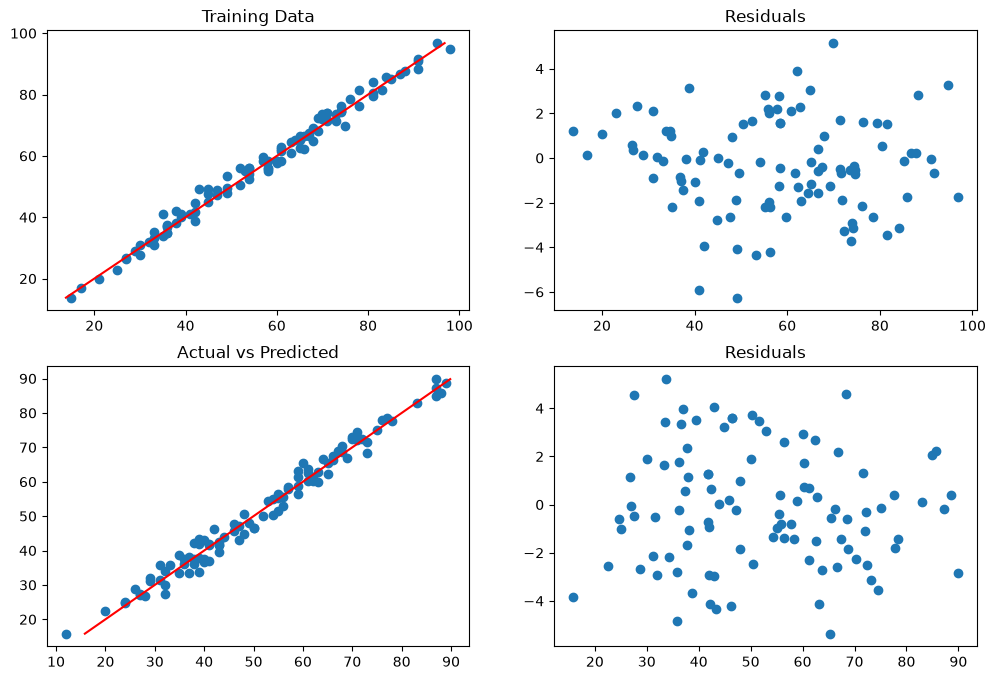

In [86]:
# Initialise sample for visualisation
multi_xtrain_vis = multi_xtrain[:100]
ytrain_vis = ytrain[:100]
multi_xtest_vis = multi_xtest[:100]
ytest_vis = ytest[:100]
ytrain_pred = np.dot(multi_xtrain_vis, w) + b
ytest_pred = np.dot(multi_xtest_vis, w) + b
train_residuals = ytrain_vis - ytrain_pred
test_residuals = ytest_vis - ytest_pred
ytrain_pred_vis = ytrain_pred[:100]
ytest_pred_vis = ytest_pred[:100]
train_residuals_vis = train_residuals[:100]
test_residuals_vis = test_residuals[:100]

# Visualise the results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax1.plot(ytrain_vis, ytrain_pred_vis, 'o')
ax1.plot([ytrain_pred_vis.min(), ytrain_pred_vis.max()], [ytrain_pred_vis.min(), ytrain_pred_vis.max()], 'r')
ax2.plot(ytrain_pred_vis, train_residuals_vis, 'o')
ax3.plot(ytest_vis, ytest_pred_vis, 'o')
ax3.plot([ytest_pred_vis.min(), ytest_pred_vis.max()], [ytest_pred_vis.min(), ytest_pred_vis.max()], 'r')
ax4.plot(ytest_pred_vis, test_residuals_vis, 'o')
ax1.set_title('Training Data')
ax2.set_title('Residuals')
ax3.set_title('Actual vs Predicted')
ax4.set_title('Residuals')

### Evaluation

In [87]:
# Calculate coefficient of determination
y_predicted = np.dot(multi_xtest, w) + b
ss_total = np.sum((ytest - np.mean(ytest)) ** 2)
ss_residual = np.sum((ytest - y_predicted) ** 2)
r_2 = 1 - (ss_residual / ss_total)
r_2

np.float64(0.9852579132602259)

The multiple linear regression model can account for 98.53% of variation in student performance.
This value is significantly higher than the coefficient of determination when regarding only the most correlated independent variable.

## Comparison with Libraries

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
# Split the data into training and testing sets for both single and multiple linear regression
train = raw.iloc[:int(0.8*len(raw))]
test = raw.iloc[int(0.8*len(raw)):]
multi_xtrain = train[['Hours Studied', 'Previous Scores']].values
single_xtrain = train[['Previous Scores']].values
ytrain = train['Performance Index'].values
multi_xtest = test[['Hours Studied', 'Previous Scores']].values
single_xtest = test[['Previous Scores']].values
ytest = test['Performance Index'].values

In [100]:
# Fitting models
single_model = LinearRegression()
single_model.fit(single_xtrain, ytrain)
multi_model = LinearRegression()
multi_model.fit(multi_xtrain, ytrain)

# Predicting values
single_y_pred = single_model.predict(single_xtest)
multi_y_pred = multi_model.predict(multi_xtest)

# Evaluating performance
single_r2 = r2_score(ytest, single_y_pred)
multi_r2 = r2_score(ytest, multi_y_pred)

single_r2, multi_r2

(0.8338762512610837, 0.9852579816509904)

We see that the model made from scratch has an extremely similar predictive power to the scikit-learn library using the same data.